# RLHF Training Results Visualization

This notebook visualizes PPO training results for toxicity reduction experiments with layer-wise selection.

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Optional, Any
import pandas as pd

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("Note: 'adjustText' not installed. Text labels may overlap.")
    print("Install with: pip install adjustText")

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

# Experiment Configuration

## Key Metrics for RLHF/PPO Training

Based on [TRL PPO Trainer documentation](https://huggingface.co/docs/trl/main/en/ppo_trainer):

| Metric | Description | Goal |
|--------|-------------|------|
| `objective/rlhf_reward` | Main RLHF reward (score - kl_penalty) | ↑ Increase |
| `objective/scores` | Mean reward from toxicity classifier | ↑ Increase (less toxic) |
| `objective/kl` | KL divergence from reference policy | Stay reasonable |
| `objective/entropy` | Policy entropy (action randomness) | Monitor |
| `policy/approxkl_avg` | KL between consecutive policies | Stay small |
| `loss/policy_avg` | Average policy loss | ↓ Decrease |
| `loss/value_avg` | Average value loss | ↓ Decrease |

## Method Definitions

Each method is defined by components matching `launch_experiments.sh`:
1. **Data Selection**: `NA` (none) or `GREATS` (gradient-based selection)
2. **Optimizer**: `Regular` (standard AdamW) or `MeSO` (memory-efficient second-order)
3. **Compression**: `NA`, `GraSS` (gradient sparse sketch), or `LoGra` (low-rank gradient)
4. **Training Type**: `full` (full fine-tuning) or `lora` (LoRA fine-tuning)
5. **Second-Order**: `False` or `True` - enables greedy selection with second-order interactions

In [17]:
# ============================================
# Configuration
# ============================================
model = 'llama3-1b'  # Model to filter experiments by

# Output directory - relative to notebook location (experiment_rlhf/)
out_dir = "outputs"

# ============================================
# Plot Filtering Options
# ============================================
show_second_order = True      # Include +2nd methods
show_lora = True              # Include LoRA methods
show_meso = True              # Include MeSO optimizer methods
show_full_ft = True           # Include full fine-tuning methods

In [18]:
# Method display name mappings (for reference)
# Experiments are auto-discovered from directories
# Directory format: rlhf-{selection}-{optimizer}-{compression}-{model}-{type}-lr{lr}-b{batch}-s{seed}
#
# Example directories:
#   rlhf-NA-Regular-GraSS-llama3-1b-lora-lr1.41e-5-b32-s42      -> PPO Baseline (LoRA)
#   rlhf-GREATS-Regular-GraSS-llama3-1b-lora-lr1.41e-5-b32-s42  -> GREATS (GraSS) LoRA
#   rlhf-GREATS-MeSO-GraSS-llama3-1b-full-lr5e-6-b32-s42        -> MeSO+GREATS (GraSS)

print("Experiment directories will be auto-discovered from:", out_dir)

Experiment directories will be auto-discovered from: outputs


## Load Training Logs

In [ ]:
def parse_training_log(log_path: str) -> Dict[str, List[float]]:
    """
    Parse training log file to extract PPO metrics.

    Supports formats:
    1. TRL standard: {'eps': 1, 'objective/kl': 0.037, 'objective/scores': -0.91, ...}
    2. Custom selection: {'objective/kl': 0.037, ..., 'eps': 10} (eps can be anywhere)
    3. Legacy format: Step 10: {'loss/total': 0.181, 'reward_mean': 2.54, ...}
    4. Numpy format: {'objective/kl': np.float64(0.0), ...} (needs special handling)
    """
    metrics = {
        'episode': [],
        'objective/kl': [],
        'objective/entropy': [],
        'objective/rlhf_reward': [],
        'objective/scores': [],
        'objective/non_score_reward': [],
        'policy/approxkl_avg': [],
        'policy/clipfrac_avg': [],
        'policy/entropy_avg': [],
        'loss/policy_avg': [],
        'loss/value_avg': [],
        'val/ratio': [],
        'lr': [],
        # Additional metrics from custom selection trainer
        'loss/total': [],
        'val_loss': [],
    }

    if not Path(log_path).exists():
        return None

    import re
    step_pattern = re.compile(r'Step\s+(\d+):\s*(\{.*\})')
    # Pattern to convert np.float64(X) -> X
    numpy_pattern = re.compile(r'np\.float\d*\(([^)]+)\)')

    with open(log_path, 'r') as f:
        for line in f:
            # Check if line contains a dict-like structure
            if '{' not in line or '}' not in line:
                continue

            # Extract dict string
            start = line.find('{')
            end = line.rfind('}') + 1
            if start < 0 or end <= start:
                continue

            dict_str = line[start:end]

            # Convert numpy types: np.float64(X) -> X
            dict_str = numpy_pattern.sub(r'\1', dict_str)

            # Format 1 & 2: Dict with 'eps' key (TRL standard or unified custom format)
            if "'eps':" in dict_str or '"eps":' in dict_str:
                try:
                    dict_str_json = dict_str.replace("'", '"')
                    data = json.loads(dict_str_json)

                    metrics['episode'].append(data.get('episode', data.get('eps', 0)))
                    for key in metrics.keys():
                        if key != 'episode' and key in data:
                            metrics[key].append(data[key])
                except (json.JSONDecodeError, ValueError):
                    continue

            # Format 3: Legacy custom selection format "Step X: {...}" (no eps key)
            elif 'Step ' in line:
                match = step_pattern.search(line)
                if match:
                    try:
                        step_num = int(match.group(1))
                        dict_str = match.group(2)
                        # Convert numpy types again for the extracted dict
                        dict_str = numpy_pattern.sub(r'\1', dict_str)
                        dict_str = dict_str.replace("'", '"')
                        data = json.loads(dict_str)

                        metrics['episode'].append(step_num)

                        # Direct mappings
                        for key in metrics.keys():
                            if key != 'episode' and key in data:
                                metrics[key].append(data[key])

                        # Map legacy metrics to TRL-style metrics
                        if 'reward_mean' in data and 'objective/scores' not in data:
                            metrics['objective/scores'].append(data['reward_mean'])
                        if 'loss/kl' in data and 'objective/kl' not in data:
                            metrics['objective/kl'].append(data['loss/kl'])
                        if 'policy/approx_kl' in data and 'policy/approxkl_avg' not in data:
                            metrics['policy/approxkl_avg'].append(data['policy/approx_kl'])
                        if 'policy/clipfrac' in data and 'policy/clipfrac_avg' not in data:
                            metrics['policy/clipfrac_avg'].append(data['policy/clipfrac'])
                        if 'loss/policy' in data and 'loss/policy_avg' not in data:
                            metrics['loss/policy_avg'].append(data['loss/policy'])
                        if 'loss/value' in data and 'loss/value_avg' not in data:
                            metrics['loss/value_avg'].append(data['loss/value'])

                        # Compute approximate RLHF reward for legacy format
                        if 'reward_mean' in data and 'loss/kl' in data and 'objective/rlhf_reward' not in data:
                            rlhf_reward = data['reward_mean'] - 0.04 * data['loss/kl']
                            metrics['objective/rlhf_reward'].append(rlhf_reward)
                    except (json.JSONDecodeError, ValueError, AttributeError):
                        continue

    # Convert to numpy arrays, only include metrics with data
    if len(metrics['episode']) > 0:
        result = {}
        for k, v in metrics.items():
            if len(v) > 0:
                result[k] = np.array(v)
            else:
                result[k] = None
        return result
    return None


def load_trainer_state(checkpoint_path: str) -> Optional[Dict]:
    """Load trainer state from checkpoint directory."""
    state_path = Path(checkpoint_path) / 'trainer_state.json'
    if state_path.exists():
        with open(state_path, 'r') as f:
            return json.load(f)
    return None


def discover_experiments(base_dir: str, model_filter: str = None) -> Dict[str, str]:
    """
    Auto-discover experiment directories based on naming convention.

    Directory format: rlhf-{selection}-{optimizer}-{compression}-{model}-{type}-lr{lr}-b{batch}-s{seed}

    Returns dict mapping friendly names to directory paths.
    """
    experiments = {}
    base_path = Path(base_dir)

    if not base_path.exists():
        return experiments

    for dir_path in base_path.iterdir():
        if not dir_path.is_dir():
            continue

        dir_name = dir_path.name

        # Skip test directories
        if dir_name.startswith('test_'):
            continue

        # Check if it matches RLHF pattern
        if not dir_name.startswith('rlhf-'):
            continue

        # Apply model filter if specified
        if model_filter and model_filter not in dir_name:
            continue

        # Parse directory name to create friendly label
        parts = dir_name.split('-')
        if len(parts) >= 5:
            # rlhf-{selection}-{optimizer}-{compression}-...
            selection = parts[1]  # NA or GREATS
            optimizer = parts[2]  # Regular or MeSO
            compression = parts[3]  # GraSS, LoGra, NA

            # Check for 2nd order flag
            has_2nd = '2nd' in dir_name

            # Check for training type (lora or full)
            is_lora = 'lora' in dir_name
            training_type = 'LoRA' if is_lora else 'Full'

            # Build friendly name
            if selection == 'NA':
                friendly = f'PPO Baseline ({training_type})'
            else:
                friendly = f'{selection}'
                if optimizer != 'Regular':
                    friendly = f'{optimizer}+{friendly}'
                friendly = f'{friendly} ({compression})'
                if is_lora:
                    friendly = f'{friendly} LoRA'
                if has_2nd:
                    friendly = f'{friendly} +2nd'

            experiments[friendly] = str(dir_path)

    return experiments


# Legacy function for backward compatibility
def build_experiment_path(method_name: str, config: Dict) -> str:
    """
    Build experiment directory path based on naming convention from train.sh.

    Note: Use discover_experiments() instead for auto-discovery.
    """
    if method_name not in method_definitions:
        return None

    data_selection, optimizer, compression, training_type, use_second_order = method_definitions[method_name]

    # Build method string - note: baselines still use GraSS in actual naming
    if data_selection == 'NA':
        method_str = f"{data_selection}-{optimizer}-GraSS"  # Baselines use GraSS
    else:
        method_str = f"{data_selection}-{optimizer}-{compression}"

    if use_second_order:
        method_str = f"{method_str}-2nd"

    job_type = training_type
    lr = config['lr']
    batch = config['batch_size']
    seed = config['seed']

    dir_name = f"rlhf-{method_str}-{model}-{job_type}-lr{lr}-b{batch}-s{seed}"
    return f"{out_dir}/{dir_name}"

In [22]:
# Auto-discover experiment directories
experiments = discover_experiments(out_dir, model_filter=model)

# Load all results
results = {}
print(f"Loading results for: {model} RLHF experiments")
print("=" * 60)

if len(experiments) == 0:
    print(f"No experiments found in {out_dir}/")
    print("Expected directory format: rlhf-{selection}-{optimizer}-{compression}-{model}-{type}-lr{lr}-b{batch}-s{seed}")
else:
    for name, path in experiments.items():
        log_path = f"{path}/train.log"
        data = parse_training_log(log_path)
        if data is not None and len(data.get('episode', [])) > 0:
            results[name] = data
            n_points = len(data['episode'])
            print(f"✓ {name}: {n_points} data points")
        else:
            print(f"✗ {name}: No training data found")

print("=" * 60)
print(f"Loaded {len(results)}/{len(experiments)} experiments")

Loading results for: llama3-1b RLHF experiments
✓ PPO Baseline (Full): 20 data points
✓ PPO Baseline (LoRA): 20 data points
✓ GREATS (GraSS) LoRA: 18 data points
Loaded 3/3 experiments


## Plot RLHF Reward Over Training

The key metric for PPO training: `objective/rlhf_reward` should increase over training.
For toxicity reduction, `objective/scores` should also increase (P(not_hate) - P(hate)).

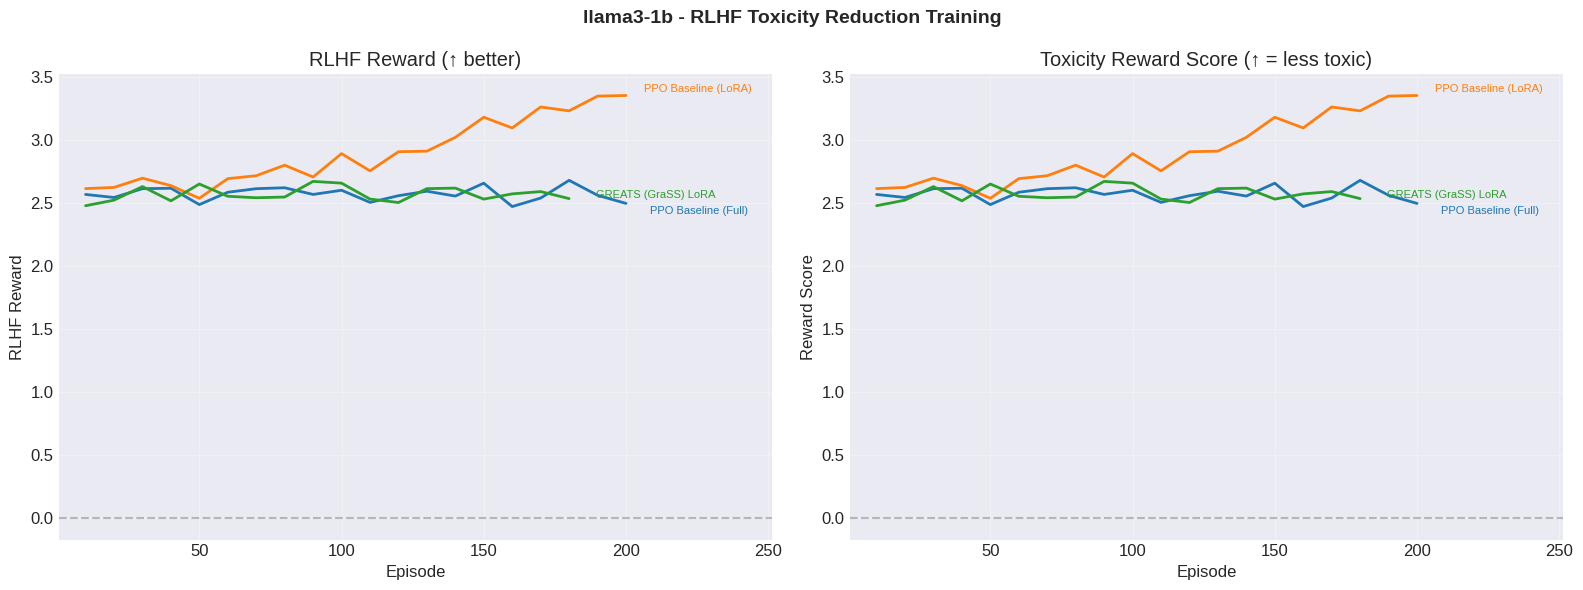

In [23]:
if len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model} - RLHF Toxicity Reduction Training', fontsize=14, fontweight='bold')

    # Plot RLHF Reward
    ax = axes[0]
    texts = []
    for name, data in results.items():
        if data.get('objective/rlhf_reward') is not None:
            episodes = data['episode']
            rewards = data['objective/rlhf_reward']
            line, = ax.plot(episodes, rewards, linewidth=2, label=name)
            if HAS_ADJUST_TEXT:
                texts.append(ax.text(episodes[-1], rewards[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel('Episode')
    ax.set_ylabel('RLHF Reward')
    ax.set_title('RLHF Reward (↑ better)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    if HAS_ADJUST_TEXT and texts:
        ax.set_xlim(right=ax.get_xlim()[1] * 1.2)
        adjust_text(texts, ax=ax)
    else:
        ax.legend(loc='best', fontsize=8)

    # Plot Reward Scores (from toxicity classifier)
    ax = axes[1]
    texts = []
    for name, data in results.items():
        if data.get('objective/scores') is not None:
            episodes = data['episode']
            scores = data['objective/scores']
            line, = ax.plot(episodes, scores, linewidth=2, label=name)
            if HAS_ADJUST_TEXT:
                texts.append(ax.text(episodes[-1], scores[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward Score')
    ax.set_title('Toxicity Reward Score (↑ = less toxic)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    if HAS_ADJUST_TEXT and texts:
        ax.set_xlim(right=ax.get_xlim()[1] * 1.2)
        adjust_text(texts, ax=ax)
    else:
        ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No results to plot. Run experiments first.")

## Plot KL Divergence and Policy Metrics

/tmp/ipykernel_447947/861855122.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8)


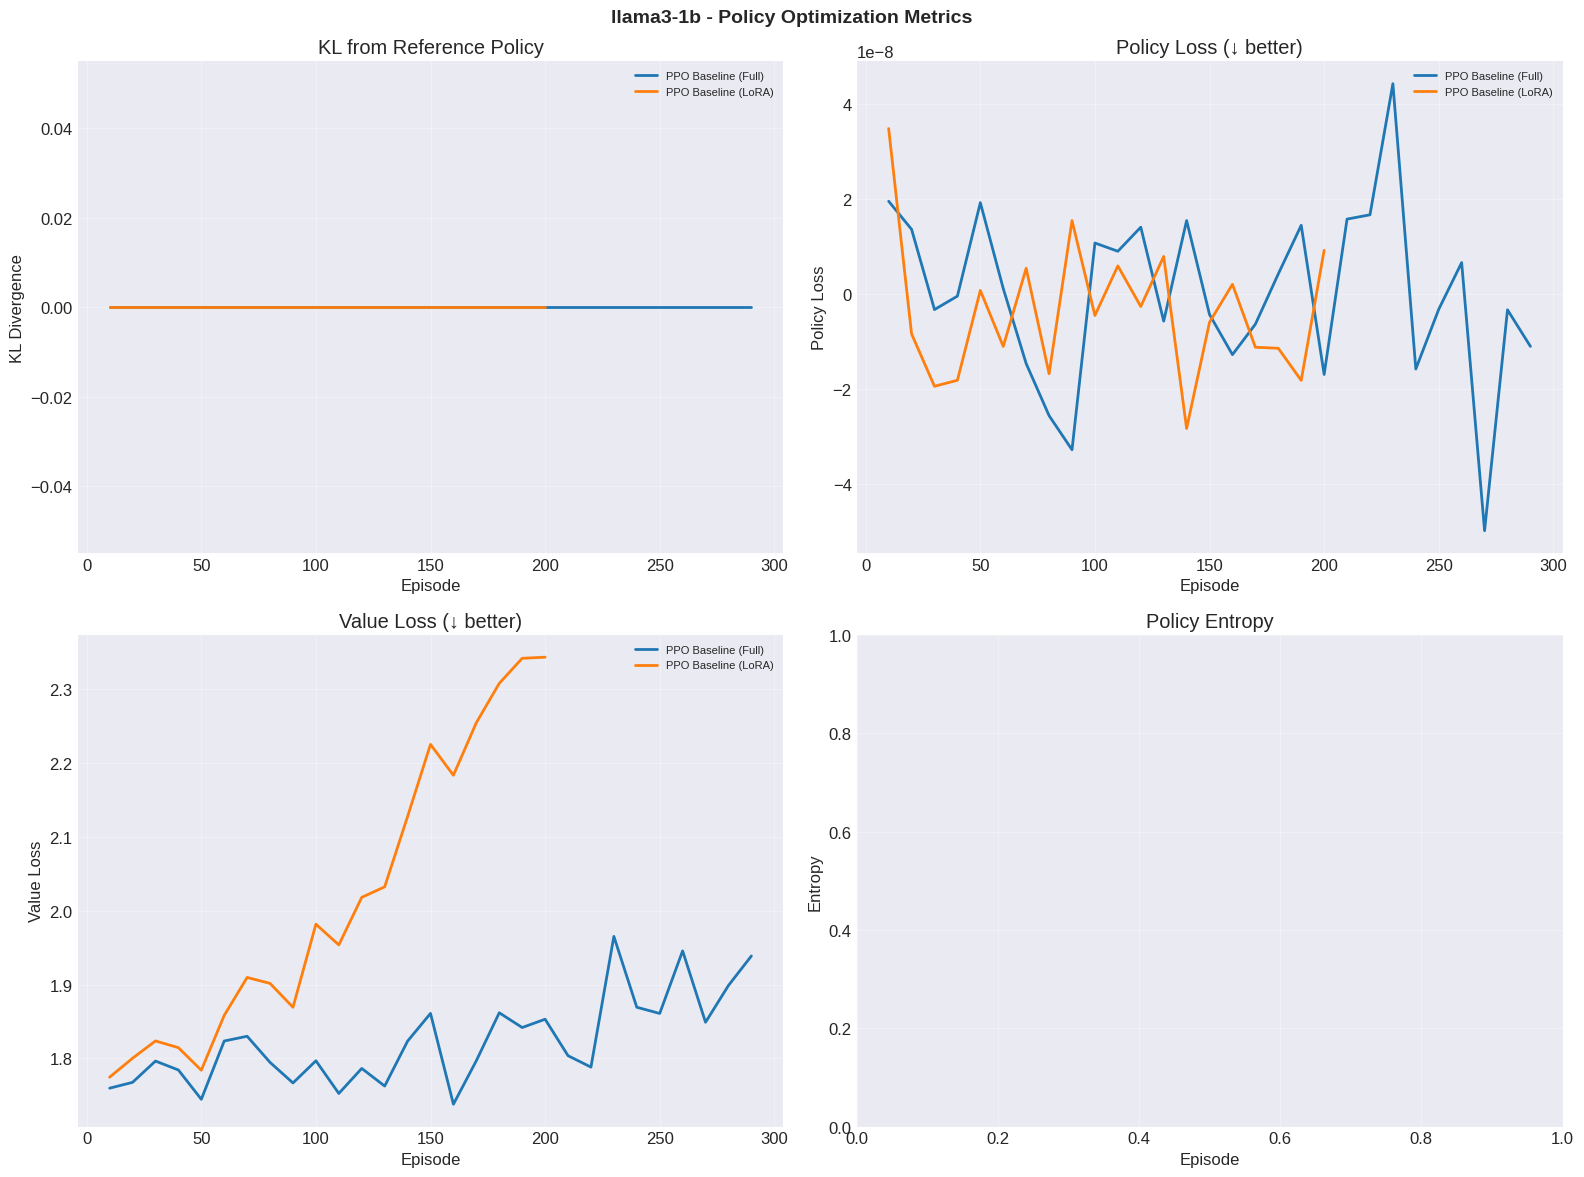

In [7]:
if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{model} - Policy Optimization Metrics', fontsize=14, fontweight='bold')

    # Plot KL Divergence (from reference)
    ax = axes[0, 0]
    for name, data in results.items():
        if data.get('objective/kl') is not None:
            ax.plot(data['episode'], data['objective/kl'], linewidth=2, label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('KL Divergence')
    ax.set_title('KL from Reference Policy')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    # Plot Policy Loss
    ax = axes[0, 1]
    for name, data in results.items():
        if data.get('loss/policy_avg') is not None:
            ax.plot(data['episode'], data['loss/policy_avg'], linewidth=2, label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Policy Loss')
    ax.set_title('Policy Loss (↓ better)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    # Plot Value Loss
    ax = axes[1, 0]
    for name, data in results.items():
        if data.get('loss/value_avg') is not None:
            ax.plot(data['episode'], data['loss/value_avg'], linewidth=2, label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Value Loss')
    ax.set_title('Value Loss (↓ better)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    # Plot Policy Entropy
    ax = axes[1, 1]
    for name, data in results.items():
        if data.get('policy/entropy_avg') is not None:
            ax.plot(data['episode'], data['policy/entropy_avg'], linewidth=2, label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Entropy')
    ax.set_title('Policy Entropy')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

## Plot PPO-Specific Metrics (Clipping, Ratio)

/tmp/ipykernel_447947/126289783.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8)


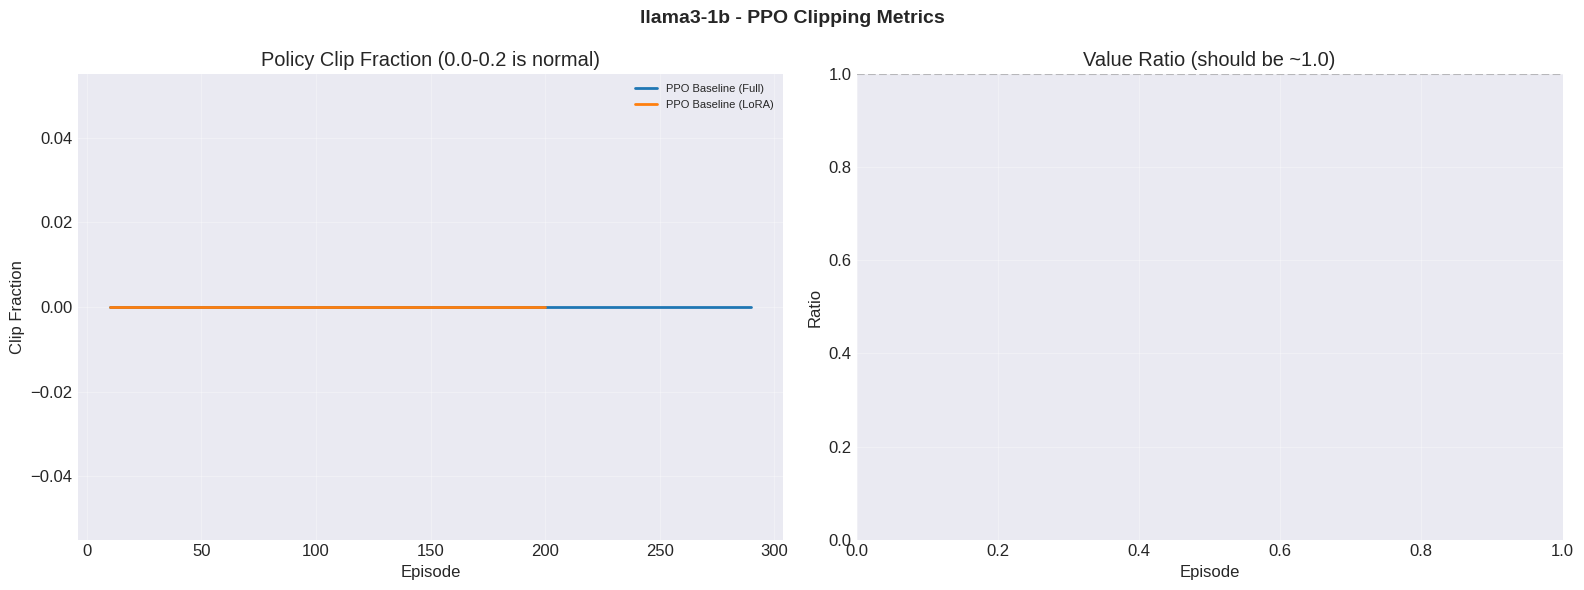

In [8]:
if len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model} - PPO Clipping Metrics', fontsize=14, fontweight='bold')

    # Plot Clip Fraction
    ax = axes[0]
    for name, data in results.items():
        if data.get('policy/clipfrac_avg') is not None:
            ax.plot(data['episode'], data['policy/clipfrac_avg'], linewidth=2, label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Clip Fraction')
    ax.set_title('Policy Clip Fraction (0.0-0.2 is normal)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    # Plot Value Ratio
    ax = axes[1]
    for name, data in results.items():
        if data.get('val/ratio') is not None:
            ax.plot(data['episode'], data['val/ratio'], linewidth=2, label=name)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Ratio')
    ax.set_title('Value Ratio (should be ~1.0)')
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

## Compare Final Performance

In [9]:
if len(results) > 0:
    print(f"\n{'='*90}")
    print(f"Final Performance Summary: {model} RLHF")
    print(f"{'='*90}")
    print(f"{'Method':<30} {'RLHF Reward':<15} {'Toxicity Score':<15} {'KL Div':<12} {'Episodes':<10}")
    print("-" * 90)

    # Collect final metrics
    summary_data = []
    for name, data in results.items():
        final_reward = data['objective/rlhf_reward'][-1] if data.get('objective/rlhf_reward') is not None else None
        final_score = data['objective/scores'][-1] if data.get('objective/scores') is not None else None
        final_kl = data['objective/kl'][-1] if data.get('objective/kl') is not None else None
        n_episodes = data['episode'][-1] if len(data['episode']) > 0 else 0

        summary_data.append({
            'method': name,
            'rlhf_reward': final_reward,
            'toxicity_score': final_score,
            'kl_div': final_kl,
            'episodes': n_episodes
        })

    # Sort by toxicity score (higher is better = less toxic)
    summary_data = sorted(summary_data, key=lambda x: x['toxicity_score'] if x['toxicity_score'] is not None else -999, reverse=True)

    for item in summary_data:
        reward_str = f"{item['rlhf_reward']:.4f}" if item['rlhf_reward'] is not None else 'N/A'
        score_str = f"{item['toxicity_score']:.4f}" if item['toxicity_score'] is not None else 'N/A'
        kl_str = f"{item['kl_div']:.4f}" if item['kl_div'] is not None else 'N/A'
        print(f"{item['method']:<30} {reward_str:<15} {score_str:<15} {kl_str:<12} {item['episodes']:<10}")

    print("=" * 90)
    print("\nNote: Higher toxicity score = less toxic output (P(not_hate) - P(hate))")
else:
    print("No results available.")


Final Performance Summary: llama3-1b RLHF
Method                         RLHF Reward     Toxicity Score  KL Div       Episodes  
------------------------------------------------------------------------------------------
PPO Baseline (LoRA)            3.3532          3.3532          0.0000       200       
PPO Baseline (Full)            2.7939          2.7939          0.0000       290       

Note: Higher toxicity score = less toxic output (P(not_hate) - P(hate))


## Plot Improvement Bar Chart

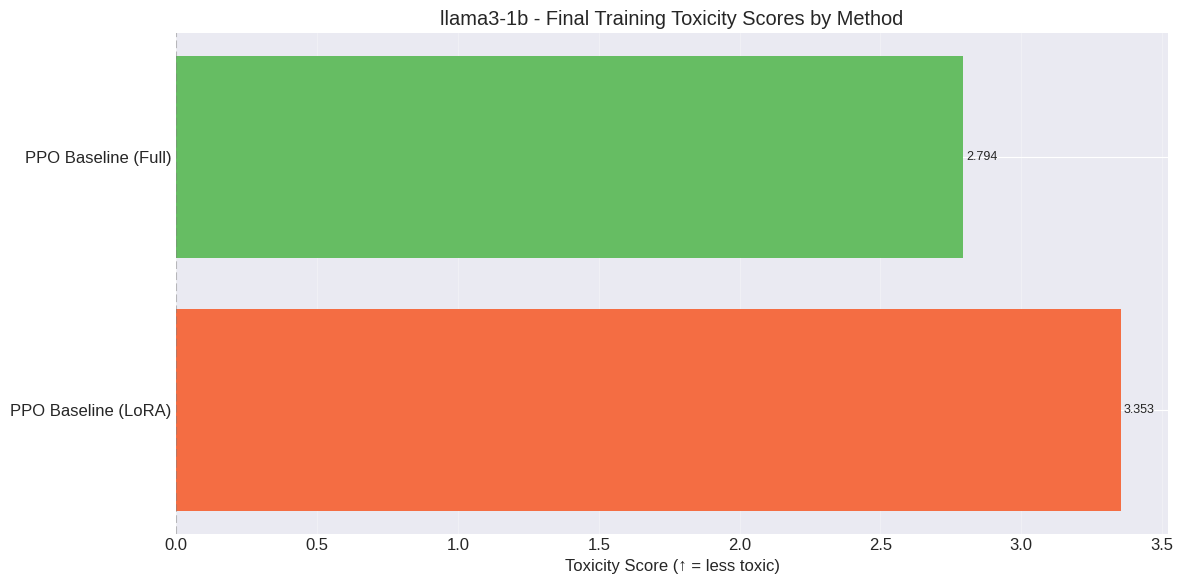

In [10]:
if len(results) > 0:
    # Extract final toxicity scores
    methods = []
    scores = []
    for name, data in results.items():
        if data.get('objective/scores') is not None:
            methods.append(name)
            scores.append(data['objective/scores'][-1])

    if len(methods) > 0:
        # Sort by score
        sorted_indices = np.argsort(scores)[::-1]  # Descending (higher = better)
        methods = [methods[i] for i in sorted_indices]
        scores = [scores[i] for i in sorted_indices]

        # Create bar chart
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(methods)))
        bars = ax.barh(range(len(methods)), scores, color=colors)
        ax.set_yticks(range(len(methods)))
        ax.set_yticklabels(methods)
        ax.set_xlabel('Toxicity Score (↑ = less toxic)')
        ax.set_title(f'{model} - Final Training Toxicity Scores by Method')
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3, axis='x')

        # Add value labels
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

## Smoothed Training Reward Progression

Visualize reward trend over training with smoothing to reduce noise.

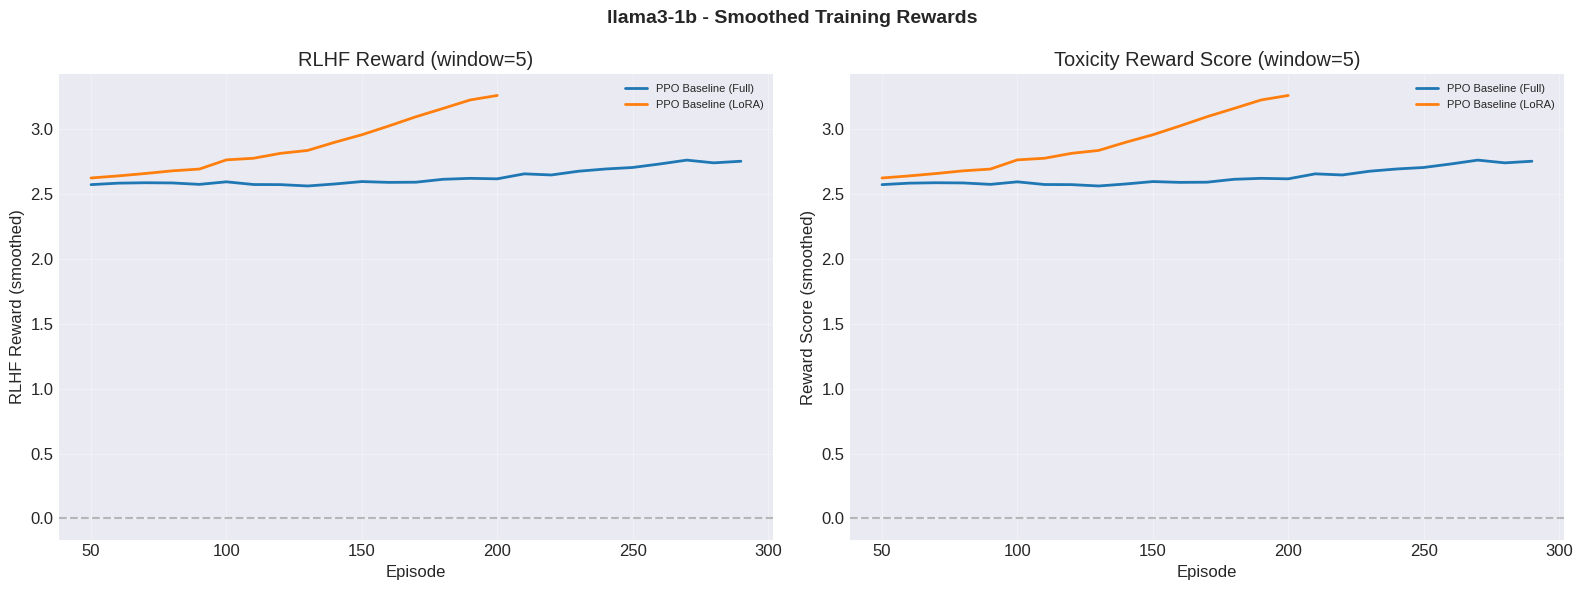

In [11]:
def smooth(data, window=5):
    """Apply moving average smoothing."""
    if len(data) < window:
        return data
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

if len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model} - Smoothed Training Rewards', fontsize=14, fontweight='bold')

    window = 5  # Smoothing window size

    # Plot Smoothed RLHF Reward
    ax = axes[0]
    for name, data in results.items():
        if data.get('objective/rlhf_reward') is not None:
            rewards = data['objective/rlhf_reward']
            if len(rewards) >= window:
                smoothed = smooth(rewards, window)
                # Adjust episode axis to match smoothed length
                episodes = data['episode'][window-1:][:len(smoothed)]
                ax.plot(episodes, smoothed, linewidth=2, label=name)
            else:
                ax.plot(data['episode'], rewards, linewidth=2, label=name, alpha=0.5)

    ax.set_xlabel('Episode')
    ax.set_ylabel('RLHF Reward (smoothed)')
    ax.set_title(f'RLHF Reward (window={window})')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.legend(loc='best', fontsize=8)

    # Plot Smoothed Reward Scores
    ax = axes[1]
    for name, data in results.items():
        if data.get('objective/scores') is not None:
            scores = data['objective/scores']
            if len(scores) >= window:
                smoothed = smooth(scores, window)
                episodes = data['episode'][window-1:][:len(smoothed)]
                ax.plot(episodes, smoothed, linewidth=2, label=name)
            else:
                ax.plot(data['episode'], scores, linewidth=2, label=name, alpha=0.5)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward Score (smoothed)')
    ax.set_title(f'Toxicity Reward Score (window={window})')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

## Test Toxicity Evaluation

Load and visualize toxicity scores from held-out test set evaluation.

The test evaluation measures:
- **Mean Toxicity**: Average toxicity score on generated text (lower = better)
- **Toxicity Rate**: Fraction of generations classified as toxic (lower = better)
- **Max Toxicity**: Maximum toxicity observed (lower = better)

In [12]:
def load_toxicity_eval(eval_path: str) -> Optional[Dict]:
    """
    Load toxicity evaluation results from JSON file.

    Expected format:
    {
        "mean_toxicity": float,
        "toxicity_rate": float,  # fraction of toxic samples
        "max_toxicity": float,
        "num_samples": int,
        "samples": [{"prompt": str, "response": str, "toxicity": float}, ...]
    }
    """
    if not Path(eval_path).exists():
        return None

    with open(eval_path, 'r') as f:
        return json.load(f)


# Load toxicity evaluation results using discovered experiments
eval_results = {}
print("Loading toxicity evaluation results...")
print("=" * 60)

if len(experiments) == 0:
    print("No experiments discovered. Run the discovery cell first.")
else:
    for name, path in experiments.items():
        # Try multiple possible evaluation file locations
        eval_paths = [
            f"{path}/toxicity_eval.json",
            f"{path}/eval_results.json",
            f"{path}/final/toxicity_eval.json",
        ]

        for eval_path in eval_paths:
            data = load_toxicity_eval(eval_path)
            if data is not None:
                eval_results[name] = data
                mean_tox = data.get('mean_toxicity', 'N/A')
                tox_rate = data.get('toxicity_rate', 'N/A')
                if isinstance(mean_tox, float):
                    print(f"✓ {name}: Mean Toxicity={mean_tox:.4f}, Rate={tox_rate:.2%}")
                else:
                    print(f"✓ {name}: Loaded evaluation data")
                break
        else:
            print(f"✗ {name}: No evaluation file found")

print("=" * 60)
print(f"Loaded {len(eval_results)}/{len(experiments)} evaluation results")

Loading toxicity evaluation results...
✗ PPO Baseline (Full): No evaluation file found
✗ PPO Baseline (LoRA): No evaluation file found
Loaded 0/2 evaluation results


In [13]:
if len(eval_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model} - Test Toxicity Evaluation', fontsize=14, fontweight='bold')

    # Collect data
    methods = []
    mean_toxicities = []
    toxicity_rates = []

    for name, data in eval_results.items():
        methods.append(name)
        mean_toxicities.append(data.get('mean_toxicity', np.nan))
        tox_rate = data.get('toxicity_rate', data.get('toxic_fraction', np.nan))
        toxicity_rates.append(tox_rate if isinstance(tox_rate, float) else np.nan)

    # Sort by mean toxicity (lower is better)
    sorted_indices = np.argsort(mean_toxicities)
    methods = [methods[i] for i in sorted_indices]
    mean_toxicities = [mean_toxicities[i] for i in sorted_indices]
    toxicity_rates = [toxicity_rates[i] for i in sorted_indices]

    # Plot Mean Toxicity
    ax = axes[0]
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(methods)))  # Reversed: red=high, green=low
    bars = ax.barh(range(len(methods)), mean_toxicities, color=colors)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods)
    ax.set_xlabel('Mean Toxicity Score (↓ better)')
    ax.set_title('Mean Toxicity on Test Set')
    ax.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, mean_toxicities)):
        if not np.isnan(val):
            ax.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=9)

    # Plot Toxicity Rate
    ax = axes[1]
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(methods)))
    bars = ax.barh(range(len(methods)), [r * 100 if not np.isnan(r) else 0 for r in toxicity_rates], color=colors)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods)
    ax.set_xlabel('Toxicity Rate % (↓ better)')
    ax.set_title('Fraction of Toxic Generations')
    ax.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, toxicity_rates)):
        if not np.isnan(val):
            ax.text(val * 100 + 0.5, i, f'{val:.1%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No evaluation results to plot.")
    print("\\nTo generate evaluation results, run:")
    print("  python experiment_rlhf/eval.py --checkpoint_path <path> --output_file toxicity_eval.json")

No evaluation results to plot.
\nTo generate evaluation results, run:
  python experiment_rlhf/eval.py --checkpoint_path <path> --output_file toxicity_eval.json


## Training Reward vs Test Toxicity Comparison

Compare the training reward signal (from PPO) with actual test toxicity to verify alignment.

In [14]:
# Compare training reward with test toxicity
if len(results) > 0 and len(eval_results) > 0:
    # Find methods with both training and eval results
    common_methods = set(results.keys()) & set(eval_results.keys())

    if len(common_methods) >= 2:
        train_scores = []
        test_toxicities = []
        method_names = []

        for name in common_methods:
            if results[name].get('objective/scores') is not None:
                train_scores.append(results[name]['objective/scores'][-1])
                test_toxicities.append(eval_results[name].get('mean_toxicity', np.nan))
                method_names.append(name)

        # Filter out NaN values
        valid = [i for i, (ts, tt) in enumerate(zip(train_scores, test_toxicities)) if not np.isnan(tt)]

        if len(valid) >= 2:
            fig, ax = plt.subplots(figsize=(10, 8))

            train_scores_valid = [train_scores[i] for i in valid]
            test_toxicities_valid = [test_toxicities[i] for i in valid]
            method_names_valid = [method_names[i] for i in valid]

            # Scatter plot
            scatter = ax.scatter(train_scores_valid, test_toxicities_valid, s=150, c=range(len(valid)), cmap='viridis', alpha=0.7, edgecolors='black')

            # Add method labels
            for i, name in enumerate(method_names_valid):
                ax.annotate(name, (train_scores_valid[i], test_toxicities_valid[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)

            ax.set_xlabel('Training Reward Score (↑ = less toxic in training)')
            ax.set_ylabel('Test Mean Toxicity (↓ = less toxic in test)')
            ax.set_title(f'{model} - Training Reward vs Test Toxicity')
            ax.grid(True, alpha=0.3)

            # Add correlation
            if len(train_scores_valid) > 2:
                corr = np.corrcoef(train_scores_valid, test_toxicities_valid)[0, 1]
                ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes,
                       fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

                # Note about expected correlation
                ax.text(0.05, 0.88, '(Negative correlation expected: higher reward → lower toxicity)',
                       transform=ax.transAxes, fontsize=9, verticalalignment='top', style='italic')

            plt.tight_layout()
            plt.show()
        else:
            print("Not enough valid data points for comparison.")
    else:
        print(f"Need at least 2 methods with both training and eval results. Found: {len(common_methods)}")
else:
    print("Need both training results and evaluation results for comparison.")

Need both training results and evaluation results for comparison.


## Export Results to CSV

In [15]:
if len(results) > 0:
    # Create DataFrame with final metrics
    export_data = []
    for name, data in results.items():
        export_data.append({
            'method': name,
            'final_rlhf_reward': data['objective/rlhf_reward'][-1] if data.get('objective/rlhf_reward') is not None else None,
            'final_toxicity_score': data['objective/scores'][-1] if data.get('objective/scores') is not None else None,
            'final_kl': data['objective/kl'][-1] if data.get('objective/kl') is not None else None,
            'final_policy_loss': data['loss/policy_avg'][-1] if data.get('loss/policy_avg') is not None else None,
            'final_value_loss': data['loss/value_avg'][-1] if data.get('loss/value_avg') is not None else None,
            'num_episodes': data['episode'][-1] if len(data['episode']) > 0 else 0,
        })

    df = pd.DataFrame(export_data)

    # Save to CSV
    csv_path = f'{out_dir}/rlhf_results_summary_{model}.csv'
    df.to_csv(csv_path, index=False)
    print(f"Results saved to: {csv_path}")

    # Display table
    display(df)
else:
    print("No results to export.")

Results saved to: outputs/rlhf_results_summary_llama3-1b.csv


,method,final_rlhf_reward,final_toxicity_score,final_kl,final_policy_loss,final_value_loss,num_episodes
0,PPO Baseline (Full),2.793892,2.793892,0.0,-1.107487e-08,1.938784,290
1,PPO Baseline (LoRA),3.353197,3.353197,0.0,9.139380e-09,2.343351,200
